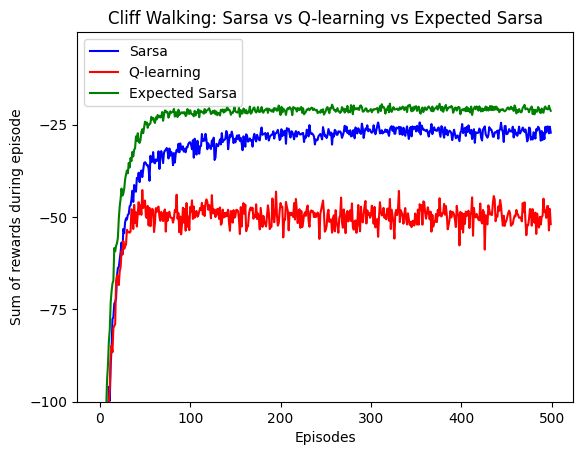

Q-values at goal state (SARSA): [0. 0. 0. 0.]
Q-values at goal state (Q-learning): [0. 0. 0. 0.]
Q-values at goal state (Expected SARSA): [0. 0. 0. 0.]


In [2]:
import numpy as np

class CliffWalking:
  def __init__(self, height=4, width=12):
    self.height = height
    self.width = width
    self.start = (self.height - 1, 0) #top-left cell is (0, 0)
    self.goal = (self.height - 1, self.width - 1)
    self.reset()

  def reset(self):
    self.position = self.start
    return self.state()

  def state(self):
    return self.position[0] * self.width + self.position[1] #flatten(row * width + col)

  def walk(self, action):
    row, col = self.position

    if action == 0: #up
      row = max(0, row - 1)
    elif action == 1: #right
      col = min(col + 1, self.width - 1)
    elif action == 2: #down
      row = min(self.height - 1, row + 1)
    elif action == 3: #left
      col = max(col - 1, 0)

    new_position = (row, col)


    #Rules and Reward
    if row == self.height - 1 and 1 <= col <= self.width -2: #walk into the cliff region
      reward = -100
      new_position = self.start
      over = False
    elif new_position == self.goal: #walk to goal
      reward = -1
      over = True #game over
    else:
      reward = -1
      over = False

    self.position = new_position
    return self.state(), reward, over

  def states(self):
    return self.height * self.width

  def actions(self):
    return 4

#play game
env = CliffWalking()

gamma = 1
epsilon = 0.1
episodes = 500
alpha = 0.5

def epsilon_greedy(state, Q, epsilon):
  if np.random.rand() < epsilon:
    return np.random.randint(env.actions())
  else:
    return np.argmax(Q[state])

def expected(Q, state, epsilon):
  action_probability = np.ones(Q.shape[1]) * (epsilon / Q.shape[1])
  best_action = np.argmax(Q[state])
  action_probability[best_action] += 1.0 - epsilon
  return np.dot(Q[state], action_probability)

runs = 1000
rewards_sarsa_all = []
rewards_q_all = []
rewards_expected_sarsa_all = []

for run in range(runs):
  Q_sarsa = np.zeros((env.states(), env.actions()))
  Q_q = np.zeros((env.states(), env.actions()))
  Q_expected_sarsa = np.zeros((env.states(), env.actions()))
  rewards_sarsa = []
  rewards_q = []
  rewards_expected_sarsa = []

  #sarsa
  for episode in range(episodes):
    state_sarsa = env.reset()
    action_sarsa = epsilon_greedy(state_sarsa, Q_sarsa, epsilon)
    total_reward_sarsa = 0

    while True:
      next_state_sarsa, reward_sarsa, over_sarsa = env.walk(action_sarsa)
      next_action_sarsa = epsilon_greedy(next_state_sarsa, Q_sarsa, epsilon)
      Q_sarsa[state_sarsa][action_sarsa] += alpha * (reward_sarsa + gamma * Q_sarsa[next_state_sarsa][next_action_sarsa] - Q_sarsa[state_sarsa][action_sarsa])

      state_sarsa = next_state_sarsa
      action_sarsa = next_action_sarsa
      total_reward_sarsa += reward_sarsa

      if over_sarsa:
        break

    rewards_sarsa.append(total_reward_sarsa)

  #q-learning
  for episode in range(episodes):
    state_q = env.reset()
    total_reward_q = 0

    while True:
      action_q = epsilon_greedy(state_q, Q_q, epsilon)
      next_state_q, reward_q, over_q = env.walk(action_q)
      best_action_q = np.argmax(Q_q[next_state_q]) #only for updating Q
      Q_q[state_q][action_q] += alpha * (reward_q + gamma * Q_q[next_state_q][best_action_q] - Q_q[state_q][action_q])

      state_q = next_state_q
      total_reward_q += reward_q

      if over_q:
        break

    rewards_q.append(total_reward_q)

  #expected sarsa
  for episode in range(episodes):
    state_expected_sarsa = env.reset()
    total_reward_expected_sarsa = 0

    while True:
      action_expected_sarsa = epsilon_greedy(state_expected_sarsa, Q_expected_sarsa, epsilon)
      next_state_expected_sarsa, reward_expected_sarsa, over_expected_sarsa = env.walk(action_expected_sarsa)
      expected_q = expected(Q_expected_sarsa, next_state_expected_sarsa, epsilon)
      Q_expected_sarsa[state_expected_sarsa][action_expected_sarsa] += alpha * (reward_expected_sarsa + gamma * expected_q - Q_expected_sarsa[state_expected_sarsa][action_expected_sarsa])

      state_expected_sarsa = next_state_expected_sarsa
      total_reward_expected_sarsa += reward_expected_sarsa

      if over_expected_sarsa:
        break

    rewards_expected_sarsa.append(total_reward_expected_sarsa)

  rewards_sarsa_all.append(rewards_sarsa)
  rewards_q_all.append(rewards_q)
  rewards_expected_sarsa_all.append(rewards_expected_sarsa)

rewards_sarsa_final = np.mean(rewards_sarsa_all, axis=0)
rewards_q_final = np.mean(rewards_q_all, axis=0)
rewards_expected_sarsa_final = np.mean(rewards_expected_sarsa_all, axis=0)

#plot
import matplotlib.pyplot as plt

plt.plot(rewards_sarsa_final, label="Sarsa", color='blue')
plt.plot(rewards_q_final, label="Q-learning", color='red')
plt.plot(rewards_expected_sarsa_final, label="Expected Sarsa", color='green')
plt.ylim(-100, 0)
plt.yticks([-100, -75, -50, -25])
plt.xlabel("Episodes")
plt.ylabel("Sum of rewards during episode")
plt.title("Cliff Walking: Sarsa vs Q-learning vs Expected Sarsa")
plt.legend()
plt.show()

goal_state = env.goal[0] * env.width + env.goal[1]
print("Q-values at goal state (SARSA):", Q_sarsa[goal_state])
print("Q-values at goal state (Q-learning):", Q_q[goal_state])
print("Q-values at goal state (Expected SARSA):", Q_expected_sarsa[goal_state])